# EDA — Missingness Analysis: `is_thoa_thuan` vs `job_level`

**Mục tiêu**: Kiểm định cơ chế missing của nhãn lương ("Thỏa thuận") có phụ thuộc vào `job_level` không —  
tức là xác định missing mechanism là **MAR** (phụ thuộc vào biến quan sát được) hay **MCAR** (hoàn toàn ngẫu nhiên)

---
## 0. Setup

In [27]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings("ignore")

# ── Paths ────────────────────────────────────────────────────────────────────
REPO_ROOT = Path("../")          # notebook nằm trong EDA/
DATA_PATH = REPO_ROOT / "data/processed/jobs_cleaned.parquet"
OUT_DIR   = Path("eda_outputs")
OUT_DIR.mkdir(exist_ok=True)

# ── Palette — nhất quán với EDA_01_Salary ────────────────────────────────────
SOURCE_PALETTE = {"topcv": "#2563EB", "itviec": "#EA580C"}
LEVEL_ORDER    = ["Thực tập sinh", "Nhân viên", "Trưởng nhóm",
                  "Trưởng/Phó phòng", "Quản lý / Giám sát", "Giám đốc"]

# Viridis palette, 1 màu cho mỗi level
LEVEL_PALETTE  = dict(zip(LEVEL_ORDER, sns.color_palette("viridis", len(LEVEL_ORDER))))

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

---
## 1. Load dữ liệu & Inspect

In [28]:
df = pd.read_parquet(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape: (3181, 27)
Columns: ['job_id', 'url', 'job_title', 'company', 'location', 'salary', 'experience', 'education', 'job_level', 'employment_type', 'industry', 'platform_required_skills', 'platform_preferred_skills', 'specialization', 'job_description', 'requirement', 'standardized_title', 'source', 'salary_raw', 'min_salary', 'max_salary', 'avg_salary', 'is_thoa_thuan', 'is_null_salary', 'is_missing_salary', 'experience_years', 'job_level_tier']


In [29]:
# Các cột cần dùng
NEEDED = ["salary", "job_level", "source"]
for col in NEEDED:
    if col not in df.columns:
        raise KeyError(f"Thiếu cột '{col}' trong dữ liệu. Kiểm tra lại file parquet.")

print("=== salary (mẫu 10 giá trị) ===")
print(df["salary"].dropna().sample(10, random_state=42).tolist())
print()
print("=== job_level value_counts ===")
print(df["job_level"].value_counts(dropna=False))
print()
print("=== source value_counts ===")
print(df["source"].value_counts())

=== salary (mẫu 10 giá trị) ===
['20 - 25 triệu', '12 - 20 triệu', '15 - 35 triệu', '10 - 25 triệu', 'Thỏa thuận', '18 - 30 triệu', 'Thỏa thuận', 'Thỏa thuận', 'Thỏa thuận', '15 - 30 triệu']

=== job_level value_counts ===
job_level
Nhân viên             1919
Trưởng nhóm            592
Senior                 253
Intern                 166
Quản lý / Giám sát     131
Trưởng/Phó phòng        79
Junior                  28
Giám đốc                 9
Fresher                  4
Name: count, dtype: int64

=== source value_counts ===
source
topcv     2440
itviec     741
Name: count, dtype: int64


In [30]:
# Báo cáo null trước khi xử lý — KHÔNG drop, chỉ ghi nhận
n_null_level = df["job_level"].isna().sum()
n_null_level_by_src = df[df["job_level"].isna()]["source"].value_counts().to_dict()
print(f"Số bản ghi có job_level null  : {n_null_level} ({n_null_level/len(df):.1%})")
print(f"Phân bổ null job_level theo source: {n_null_level_by_src}")

Số bản ghi có job_level null  : 0 (0.0%)
Phân bổ null job_level theo source: {}


---
## 2. Tạo cột `is_thoa_thuan`

In [31]:
if "is_thoa_thuan" not in df.columns:
    NEG_PATTERNS = [
        "thỏa thuận", "thoả thuận", "thoa thuan",
        "negotiable", "competitive", "you'll love it",
        "sign in to view", "very attractive", "thương lượng"
    ]
    df["is_thoa_thuan"] = df["salary"].str.lower().str.strip().apply(
        lambda x: any(p in str(x) for p in NEG_PATTERNS)
            if pd.notna(x) else True   # null salary = không có lương cụ thể
    )
    print("Đã tạo cột is_thoa_thuan")
else:
    print("Cột is_thoa_thuan đã tồn tại, dùng giá trị có sẵn.")

print(f"\nPhân bổ is_thoa_thuan:")
print(df["is_thoa_thuan"].value_counts())
print(f"Tỷ lệ thỏa thuận toàn tập: {df['is_thoa_thuan'].mean():.1%}")

Cột is_thoa_thuan đã tồn tại, dùng giá trị có sẵn.

Phân bổ is_thoa_thuan:
is_thoa_thuan
True     1703
False    1478
Name: count, dtype: int64
Tỷ lệ thỏa thuận toàn tập: 53.5%


---
## Bước 1 — Phân phối `is_thoa_thuan` theo `job_level` × `source`

In [32]:
# Tính tỷ lệ thỏa thuận và count theo job_level × source
# Chỉ dùng các bản ghi có job_level (loại null ra khỏi bảng này)
df_with_level = df[df["job_level"].notna()].copy()

stats_level = (
    df_with_level
    .groupby(["job_level", "source"])["is_thoa_thuan"]
    .agg(pct_thoa_thuan="mean", count="count")
    .reset_index()
    .sort_values("pct_thoa_thuan", ascending=False)
)
stats_level["pct_thoa_thuan_pct"] = (stats_level["pct_thoa_thuan"] * 100).round(1)
print(stats_level.to_string(index=False))

         job_level source  pct_thoa_thuan  count  pct_thoa_thuan_pct
Quản lý / Giám sát itviec        0.809524     63                81.0
            Junior itviec        0.785714     28                78.6
         Nhân viên itviec        0.763380    355                76.3
            Senior itviec        0.754941    253                75.5
           Fresher itviec        0.750000      4                75.0
          Giám đốc  topcv        0.666667      9                66.7
  Trưởng/Phó phòng  topcv        0.658228     79                65.8
       Trưởng nhóm itviec        0.657895     38                65.8
Quản lý / Giám sát  topcv        0.485294     68                48.5
         Nhân viên  topcv        0.477621   1564                47.8
       Trưởng nhóm  topcv        0.444043    554                44.4
            Intern  topcv        0.337349    166                33.7


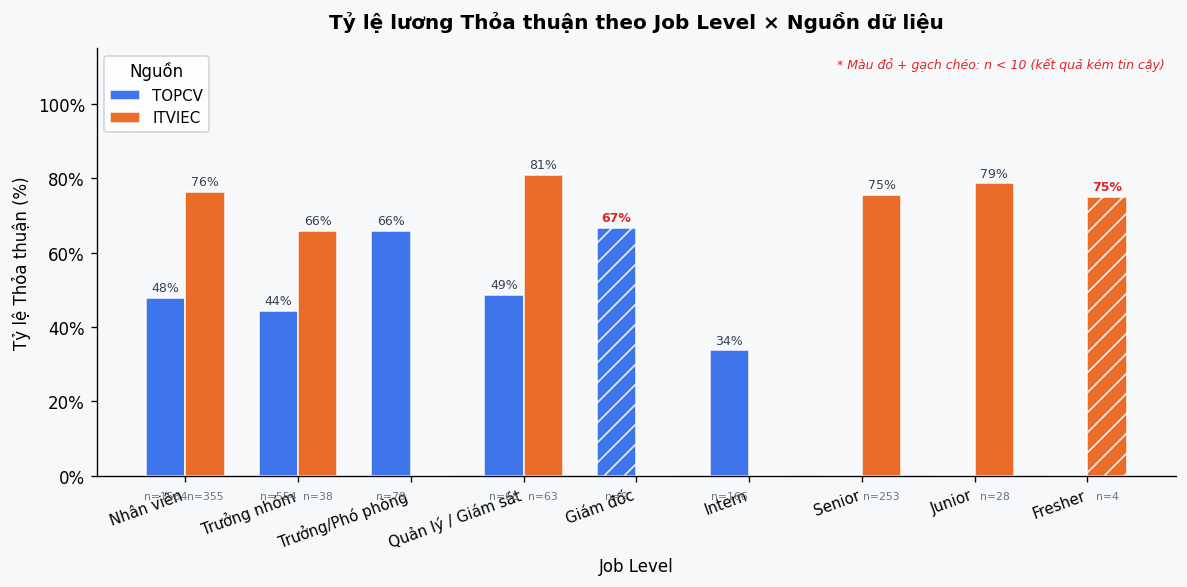

Saved: eda_outputs\missingness_by_level.png


In [33]:
# Chuẩn bị data cho plot
# Chỉ giữ các level có trong LEVEL_ORDER; level không biết thứ tự → cuối
levels_in_data = [l for l in LEVEL_ORDER if l in df_with_level["job_level"].unique()]
levels_extra   = [l for l in df_with_level["job_level"].unique() if l not in LEVEL_ORDER]
plot_order     = levels_in_data + levels_extra

# Count tổng mỗi level (dùng để annotate)
count_per_level = df_with_level.groupby("job_level")["is_thoa_thuan"].count().to_dict()
LOW_COUNT_THR   = 10   # level có count < 10 → annotate khác màu

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#F7F8FA")
ax.set_facecolor("#F7F8FA")

x_positions = np.arange(len(plot_order))
bar_width   = 0.35
sources     = ["topcv", "itviec"]
offsets     = [-bar_width / 2, bar_width / 2]

for src, offset in zip(sources, offsets):
    src_data = stats_level[stats_level["source"] == src].set_index("job_level")
    heights  = [src_data.loc[l, "pct_thoa_thuan"] if l in src_data.index else 0
                for l in plot_order]
    counts   = [src_data.loc[l, "count"] if l in src_data.index else 0
                for l in plot_order]

    bars = ax.bar(
        x_positions + offset, heights,
        width=bar_width, label=src.upper(),
        color=SOURCE_PALETTE[src], edgecolor="white", alpha=0.88
    )

    for bar, h, c in zip(bars, heights, counts):
        if c == 0:
            continue
        low = c < LOW_COUNT_THR
        # Annotate phần trăm
        ax.text(
            bar.get_x() + bar.get_width() / 2, h + 0.01,
            f"{h:.0%}",
            ha="center", va="bottom", fontsize=7.5,
            color="#DC2626" if low else "#374151",
            fontweight="bold" if low else "normal"
        )
        # Annotate count dưới bar (nếu low count → thêm hatch)
        if low:
            bar.set_hatch("//")
        ax.text(
            bar.get_x() + bar.get_width() / 2, -0.04,
            f"n={c}",
            ha="center", va="top", fontsize=6.5,
            color="#6B7280"
        )

ax.set_xticks(x_positions)
ax.set_xticklabels(plot_order, rotation=20, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0, 1.15)
ax.set_xlabel("Job Level", fontsize=10)
ax.set_ylabel("Tỷ lệ Thỏa thuận (%)", fontsize=10)
ax.set_title(
    "Tỷ lệ lương Thỏa thuận theo Job Level × Nguồn dữ liệu",
    fontsize=12, fontweight="bold", pad=12
)
ax.legend(title="Nguồn", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# Note về low-count bars
ax.text(
    0.99, 0.98,
    "* Màu đỏ + gạch chéo: n < 10 (kết quả kém tin cậy)",
    transform=ax.transAxes, ha="right", va="top",
    fontsize=7.5, color="#DC2626", style="italic"
)

plt.tight_layout()
fig.savefig(OUT_DIR / "missingness_by_level.png", bbox_inches="tight")
plt.show()
print("Saved:", OUT_DIR / "missingness_by_level.png")

---
## Bước 2 — Chi-square test: `is_thoa_thuan` ~ `job_level`

In [34]:
# Loại null job_level & level có count < 10 ra khỏi test
level_counts = df["job_level"].value_counts()
valid_levels = level_counts[level_counts >= LOW_COUNT_THR].index.tolist()
excluded_levels = level_counts[level_counts < LOW_COUNT_THR].index.tolist()

print(f"Level hợp lệ (count >= {LOW_COUNT_THR}): {valid_levels}")
print(f"Level bị loại (count < {LOW_COUNT_THR}) : {excluded_levels}")

df_test = df[df["job_level"].isin(valid_levels)].copy()
print(f"\nSố bản ghi dùng cho test: {len(df_test)} / {len(df)}")

contingency_level = pd.crosstab(df_test["job_level"], df_test["is_thoa_thuan"])
print("\nContingency table (job_level × is_thoa_thuan):")
print(contingency_level)

Level hợp lệ (count >= 10): ['Nhân viên', 'Trưởng nhóm', 'Senior', 'Intern', 'Quản lý / Giám sát', 'Trưởng/Phó phòng', 'Junior']
Level bị loại (count < 10) : ['Giám đốc', 'Fresher']

Số bản ghi dùng cho test: 3168 / 3181

Contingency table (job_level × is_thoa_thuan):
is_thoa_thuan       False  True 
job_level                       
Intern                110     56
Junior                  6     22
Nhân viên             901   1018
Quản lý / Giám sát     47     84
Senior                 62    191
Trưởng nhóm           321    271
Trưởng/Phó phòng       27     52


In [35]:
chi2_level, p_level, dof_level, expected_level = chi2_contingency(contingency_level)

print(f"Chi-square  = {chi2_level:.4f}")
print(f"p-value     = {p_level:.4e}")
print(f"df (bậc tự do) = {dof_level}")
print()
if p_level < 0.05:
    print("→ p < 0.05: Bác bỏ H0 — is_thoa_thuan KHÔNG ĐỘC LẬP với job_level")
    print("→ Kết luận: Missing mechanism là MAR (phụ thuộc vào job_level)")
else:
    print("→ p ≥ 0.05: Không đủ bằng chứng bác bỏ H0")
    print("→ Kết luận: Chưa loại trừ MCAR")

Chi-square  = 107.4423
p-value     = 6.9923e-21
df (bậc tự do) = 6

→ p < 0.05: Bác bỏ H0 — is_thoa_thuan KHÔNG ĐỘC LẬP với job_level
→ Kết luận: Missing mechanism là MAR (phụ thuộc vào job_level)


---
## Bước 3 — Chi-square test: `is_thoa_thuan` ~ `source`

In [36]:
contingency_source = pd.crosstab(df["source"], df["is_thoa_thuan"])
print("Contingency table (source × is_thoa_thuan):")
print(contingency_source)

chi2_src, p_src, dof_src, _ = chi2_contingency(contingency_source)

print(f"\nChi-square (source) = {chi2_src:.4f}")
print(f"p-value    (source) = {p_src:.4e}")
print(f"df         (source) = {dof_src}")
print()
if p_src < 0.05:
    print("→ p < 0.05: Tỷ lệ thỏa thuận khác nhau đáng kể giữa topcv và itviec")
else:
    print("→ p ≥ 0.05: Không có bằng chứng cho thấy source ảnh hưởng đến tỷ lệ thỏa thuận")

Contingency table (source × is_thoa_thuan):
is_thoa_thuan  False  True 
source                     
itviec           178    563
topcv           1300   1140

Chi-square (source) = 194.4149
p-value    (source) = 3.4571e-44
df         (source) = 1

→ p < 0.05: Tỷ lệ thỏa thuận khác nhau đáng kể giữa topcv và itviec


---
## Bước 4 — Cramér's V: Effect size

In [37]:
def cramers_v(chi2, n, r, k):
    """Cramér's V — r = số hàng, k = số cột"""
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# job_level
n_level   = contingency_level.sum().sum()
r_level, k_level = contingency_level.shape
v_level   = cramers_v(chi2_level, n_level, r_level, k_level)

# source
n_src     = contingency_source.sum().sum()
r_src, k_src = contingency_source.shape
v_src     = cramers_v(chi2_src, n_src, r_src, k_src)

def interpret_v(v):
    if v < 0.1:  return "rất yếu (< 0.1)"
    if v < 0.3:  return "yếu (0.1–0.3)"
    if v < 0.5:  return "trung bình (0.3–0.5)"
    return "mạnh (> 0.5)"

print(f"Cramér's V (job_level) = {v_level:.4f}  → {interpret_v(v_level)}")
print(f"Cramér's V (source)    = {v_src:.4f}  → {interpret_v(v_src)}")

Cramér's V (job_level) = 0.1842  → yếu (0.1–0.3)
Cramér's V (source)    = 0.2472  → yếu (0.1–0.3)


---
## Bước 5 — Heatmap tỷ lệ thỏa thuận theo `job_level × source`

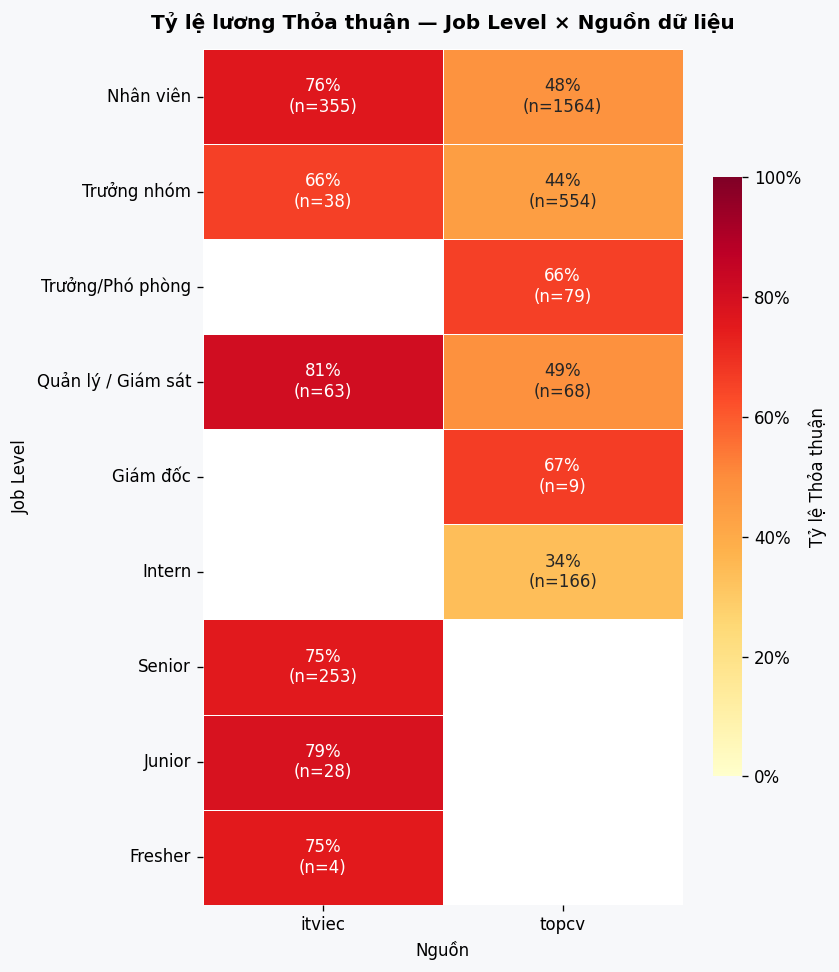

Saved: eda_outputs\missingness_heatmap.png


In [38]:
pivot = (
    df[df["job_level"].notna()]
    .groupby(["job_level", "source"])["is_thoa_thuan"]
    .mean()
    .unstack("source")
    .reindex(index=plot_order)   # đúng thứ bậc
    .dropna(how="all")           # bỏ level không có bất kỳ source nào
)

# Count để annotate thêm
pivot_count = (
    df[df["job_level"].notna()]
    .groupby(["job_level", "source"])["is_thoa_thuan"]
    .count()
    .unstack("source")
    .reindex(index=pivot.index)
)

# Annot: "XX%\n(n=YY)"
annot = pivot.copy().astype(object)
for row in pivot.index:
    for col in pivot.columns:
        val = pivot.loc[row, col]
        cnt = pivot_count.loc[row, col] if not pd.isna(pivot_count.loc[row, col]) else 0
        annot.loc[row, col] = f"{val:.0%}\n(n={int(cnt)})" if not pd.isna(val) else "N/A"

fig, ax = plt.subplots(figsize=(7, max(4, len(pivot) * 0.8 + 1)))
fig.patch.set_facecolor("#F7F8FA")

sns.heatmap(
    pivot,
    annot=annot, fmt="",
    cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.5, linecolor="white",
    ax=ax,
    cbar_kws={"format": mticker.PercentFormatter(xmax=1, decimals=0),
              "shrink": 0.7, "label": "Tỷ lệ Thỏa thuận"}
)

ax.set_title(
    "Tỷ lệ lương Thỏa thuận — Job Level × Nguồn dữ liệu",
    fontsize=12, fontweight="bold", pad=12
)
ax.set_xlabel("Nguồn", fontsize=10)
ax.set_ylabel("Job Level", fontsize=10)
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
fig.savefig(OUT_DIR / "missingness_heatmap.png", bbox_inches="tight")
plt.show()
print("Saved:", OUT_DIR / "missingness_heatmap.png")

---
## 6. Lưu kết quả thống kê

In [39]:
missingness_stats = {
    "job_level": {
        "chi2":      round(float(chi2_level), 4),
        "p_value":   float(p_level),
        "dof":       int(dof_level),
        "cramers_v": round(float(v_level), 4),
        "n_used":    int(n_level),
        "n_excluded_null": int(n_null_level),
        "levels_excluded_low_count": excluded_levels,
        "interpretation": "MAR" if p_level < 0.05 else "MCAR-compatible"
    },
    "source": {
        "chi2":      round(float(chi2_src), 4),
        "p_value":   float(p_src),
        "dof":       int(dof_src),
        "cramers_v": round(float(v_src), 4),
        "n_used":    int(n_src),
        "interpretation": "MAR" if p_src < 0.05 else "MCAR-compatible"
    }
}

with open(OUT_DIR / "missingness_stats.json", "w", encoding="utf-8") as f:
    json.dump(missingness_stats, f, ensure_ascii=False, indent=2)

print(json.dumps(missingness_stats, ensure_ascii=False, indent=2))
print("\nSaved:", OUT_DIR / "missingness_stats.json")

{
  "job_level": {
    "chi2": 107.4423,
    "p_value": 6.992261825215615e-21,
    "dof": 6,
    "cramers_v": 0.1842,
    "n_used": 3168,
    "n_excluded_null": 0,
    "levels_excluded_low_count": [
      "Giám đốc",
      "Fresher"
    ],
    "interpretation": "MAR"
  },
  "source": {
    "chi2": 194.4149,
    "p_value": 3.4571147139654333e-44,
    "dof": 1,
    "cramers_v": 0.2472,
    "n_used": 3181,
    "interpretation": "MAR"
  }
}

Saved: eda_outputs\missingness_stats.json


---
## 7. Tóm tắt kết quả

In [40]:
print("="*60)
print("KẾT QUẢ EDA — MISSINGNESS ANALYSIS")
print("="*60)
print(f"Tổng bản ghi           : {len(df):,}")
print(f"Tỷ lệ thỏa thuận tổng  : {df['is_thoa_thuan'].mean():.1%}")
print(f"Job_level null (itviec): {n_null_level:,} ({n_null_level/len(df):.1%})")
print()
print(f"Chi-square (job_level) : {chi2_level:.2f}, p = {p_level:.2e}, V = {v_level:.3f}")
print(f"Chi-square (source)    : {chi2_src:.2f}, p = {p_src:.2e}, V = {v_src:.3f}")
print()
conclusion_level = "MAR" if p_level < 0.05 else "Chưa loại trừ MCAR"
conclusion_src   = "Có sự khác biệt theo source" if p_src < 0.05 else "Không có sự khác biệt theo source"
print(f"→ Missing mechanism (job_level): {conclusion_level}")
print(f"→ Source effect                : {conclusion_src}")
print()
print("Files đã lưu:")
for f_out in sorted(OUT_DIR.glob("missingness_*")):
    print(f"  {f_out}")

KẾT QUẢ EDA — MISSINGNESS ANALYSIS
Tổng bản ghi           : 3,181
Tỷ lệ thỏa thuận tổng  : 53.5%
Job_level null (itviec): 0 (0.0%)

Chi-square (job_level) : 107.44, p = 6.99e-21, V = 0.184
Chi-square (source)    : 194.41, p = 3.46e-44, V = 0.247

→ Missing mechanism (job_level): MAR
→ Source effect                : Có sự khác biệt theo source

Files đã lưu:
  eda_outputs\missingness_by_level.png
  eda_outputs\missingness_heatmap.png
  eda_outputs\missingness_stats.json
